#  E-Commerce Customer Sentiment & Root Cause Analysis Pipeline

---

**Author:** Lidya Malak Laroum  
**Date:** June 2026  
**Tools:** Python, Pandas, NumPy, TextBlob, NLTK, Matplotlib, Seaborn  
**Dataset:** Women's Clothing E-Commerce Reviews — Kaggle  

---

##  Project Objective
Analyze 23,000+ women's clothing reviews to uncover customer sentiment 
patterns, identify key complaint themes, and provide actionable insights 
for retail decision-makers.

##  Business Questions
1. What percentage of customers recommend the products they review?
2. Which departments generate the most positive/negative sentiment?
3. What keywords appear most in negative reviews?
4. Is there a mismatch between star ratings and written sentiment?

##  Project Workflow
```
Raw Data → Cleaning → Feature Engineering → NLP Analysis → Validation → Export → Power BI
```

In [4]:
!pip install textblob tqdm

## Phase 1: Environment Setup & Library Imports

Importing all required libraries for data manipulation, 
text processing, and visualization.
All warnings are suppressed for clean output.

In [5]:
# Phase 1 — Environment Setup
import pandas as pd
import numpy as np
import re
import warnings
from textblob import TextBlob
from tqdm import tqdm
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress harmless warnings
warnings.filterwarnings('ignore')

# Enable progress bars for large dataset operations
tqdm.pandas()

# Download NLTK models
print("Downloading NLTK dependencies...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)
print(" Environment setup complete.")

 Environment setup complete.


## Phase 2: Data Ingestion & Quality Assurance

**Objective:** Load the raw dataset and immediately perform:
- Deduplication — removing exact duplicate rows
- Schema standardization — snake_case column names
- Null handling — filling missing text fields

In data science, "garbage in = garbage out."  
We must ensure clean input before any analysis begins.

In [6]:
# Phase 2 — Load & Clean Data
input_path = r'C:\Users\larou\Untitled spreadsheet - Womens Clothing E-Commerce Reviews.csv'

print(f"Loading data from: {input_path}")
df = pd.read_csv(input_path, encoding='utf-8')
print(f"Raw dataset shape: {df.shape}")

# Step A — Drop duplicates
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Dropped {initial_rows - len(df)} duplicate rows.")

# Step B — Standardize column names to snake_case
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Step C — Handle nulls in text columns
text_cols = [c for c in df.columns if any(x in c for x in ['review', 'title', 'text'])]
for col in text_cols:
    df[col] = df[col].fillna("")

# Step D — Drop rows where all text fields are empty
if text_cols:
    df = df[df[text_cols].apply(
        lambda row: any(str(val).strip() != "" for val in row), axis=1
    )]

print(f" Data cleaned. Valid rows remaining: {len(df):,}")
df.head(2)

Loading data from: C:\Users\larou\Untitled spreadsheet - Womens Clothing E-Commerce Reviews.csv
Raw dataset shape: (23486, 12)
Dropped 844 duplicate rows.
 Data cleaned. Valid rows remaining: 22,641


,transaction_id,clothing_id,age,title,review_text,rating,is_recommended,positive_feedback_count,department_name,department_name.1,class_name,review_length
0,0.0,767.0,33.0,,Absolutely wonderful - silky and sexy and comf...,4.0,1.0,0.0,Initmates,Intimate,Intimates,53.0
1,1.0,1080.0,34.0,,Love this dress! it's sooo pretty. i happene...,5.0,1.0,4.0,General,Dresses,Dresses,303.0


## Phase 3: Feature Engineering

Creating new columns to enrich the dataset:

| New Column    | Description                                               |
|    ---        |     ---                                                   |
|`full_review`  | Title + Review Text combined for NLP input                |
|`review_length`| Number of characters — longer reviews = stronger opinions |

**Hypothesis:** Angry customers write longer, more detailed reviews  
than satisfied ones. We will validate this in Phase 6.

In [7]:
# Phase 3 — Feature Engineering

# Dynamically detect title and review text columns
title_col = next((c for c in df.columns if 'title' in c), None)
text_col = next((c for c in df.columns if 'review_text' in c 
                 or c.endswith('review')), None)

def build_full_review(row):
    """Concatenates title and review text intelligently."""
    parts = []
    if title_col and str(row[title_col]).strip():
        parts.append(str(row[title_col]).strip())
    if text_col and str(row[text_col]).strip():
        parts.append(str(row[text_col]).strip())
    return " - ".join(parts)

df['full_review'] = df.apply(build_full_review, axis=1)
df['review_length'] = df['full_review'].apply(len)

print(" Feature engineering complete.")
print(f"\nSample full_review:")
print(df['full_review'].iloc[0][:150] + "...")
print(f"\nReview length stats:")
print(df['review_length'].describe().round(1))

 Feature engineering complete.

Sample full_review:
Absolutely wonderful - silky and sexy and comfortable...

Review length stats:
count    22641.0
mean       327.7
std        147.4
min         11.0
25%        203.0
50%        321.0
75%        480.0
max        559.0
Name: review_length, dtype: float64


## Phase 4: NLP Architecture — Sentiment & Keyword Extraction

Here we define the core intelligence of our pipeline:

1. **Sentiment Polarity (-1.0 to +1.0):** 
   Measures emotion. -1 = very negative, +1 = very positive.

2. **Sentiment Subjectivity (0.0 to 1.0):** 
   Measures opinion vs fact. 0 = objective, 1 = purely personal.

3. **Vibe Category:** Business-friendly label — Positive / Neutral / Negative.

4. **Keyword Extraction:** Uses NLTK Part-of-Speech (POS) tagging to extract 
   top Nouns and Adjectives — identifying *what* customers are talking about.
   A comprehensive stopword list removes noise like "i", "petite", "xs".

In [8]:
# Phase 4 — Define NLP Functions

# Comprehensive stopwords — removes noise from keywords
STOPWORDS = {
    # Pronouns
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she',
    'it', 'they', 'them', 'their', 'herself', 'himself', 'myself',
    # Articles & determiners
    'a', 'an', 'the', 'this', 'that', 'these', 'those',
    # Conjunctions & prepositions  
    'and', 'but', 'or', 'so', 'yet', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'by', 'from', 'about', 'into',
    # Common verbs
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'did', 'will', 'would',
    'could', 'should', 'may', 'might', 'can', 'shall',
    'get', 'got', 'like', 'love', 'loved', 'think', 'thought',
    'know', 'want', 'need', 'feel', 'felt', 'look', 'looked',
    'wear', 'wearing', 'worn', 'buy', 'bought', 'try', 'tried',
    # Adverbs
    'very', 'too', 'really', 'just', 'much', 'more', 'most',
    'also', 'well', 'even', 'quite', 'already', 'still', 'back',
    # Size indicators — not meaningful product attributes
    'xs', 's', 'm', 'l', 'xl', 'xxl', 'small', 'medium',
    'large', 'petite', 'tall', 'plus', 'size',
    # Typos & artifacts
    'hte', 'teh', 'wa', 'im', 'dont', 'cant',
    # Single/double letters
    'n', 'x', 'u', 'so', 'no',
}

def get_sentiment(text: str) -> tuple:
    """Calculates Polarity and Subjectivity using TextBlob."""
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0
    tb = TextBlob(text)
    return tb.sentiment.polarity, tb.sentiment.subjectivity

def get_vibe_category(polarity: float) -> str:
    """Classifies polarity into business-friendly categories."""
    if polarity > 0.1:  return 'Positive'
    elif polarity < -0.1: return 'Negative'
    else: return 'Neutral'

from textblob import Word

# General keywords — for ALL reviews (your current extract_keywords)

def extract_keywords(text: str, top_n: int = 2) -> str:
    """Extracts top Nouns/Adjectives regardless of sentiment."""
    if not isinstance(text, str) or not text.strip():
        return ''
    tokens = nltk.word_tokenize(text.lower())
    try:
        tagged = nltk.pos_tag(tokens, lang='eng')
    except:
        tagged = nltk.pos_tag(tokens)
    candidates = [
        word for word, pos in tagged
        if (pos.startswith('NN') or pos.startswith('JJ'))
        and word not in STOPWORDS
        and len(word) > 2
        and not word.isdigit()
    ]
    if not candidates:
        return ''
    return ', '.join([w for w, _ in Counter(candidates).most_common(top_n)])


# Negative keywords — filters by word sentiment

def extract_negative_keywords(text: str, top_n: int = 2) -> str:
    """Extracts only neutral/negative adjectives and nouns."""
    if not isinstance(text, str) or not text.strip():
        return ''
    tokens = nltk.word_tokenize(text.lower())
    try:
        tagged = nltk.pos_tag(tokens, lang='eng')
    except:
        tagged = nltk.pos_tag(tokens)
    candidates = []
    for word, pos in tagged:
        if not (pos.startswith('NN') or pos.startswith('JJ')):
            continue
        if word in STOPWORDS or len(word) <= 2 or word.isdigit():
            continue
        # Only keep neutral or negative words
        word_sentiment = TextBlob(word).sentiment.polarity
        if word_sentiment >= 0.1:
            continue
        candidates.append(word)
    if not candidates:
        return ''
    return ', '.join([w for w, _ in Counter(candidates).most_common(top_n)])

print(" NLP architecture defined.")

 NLP architecture defined.


## Phase 5: Pipeline Execution

Applying the NLP engine to all 22,000+ reviews.  
`tqdm` progress bars are used to monitor processing in real time.

 *Expected runtime: approximately 2 minutes.*

In [9]:
# Phase 5 — Run NLP Pipeline

print(" Starting NLP processing on all reviews...")
print("This will take approximately 2 minutes.\n")

# Run sentiment analysis with progress bar
sentiment_results = df['full_review'].progress_apply(get_sentiment)
df['sentiment_polarity']    = [r[0] for r in sentiment_results]
df['sentiment_subjectivity'] = [r[1] for r in sentiment_results]

# Classify vibe
df['vibe_category'] = df['sentiment_polarity'].apply(get_vibe_category)

# General keywords 
print("Extracting general keywords...")
df['key_keywords'] = df['full_review'].progress_apply(extract_keywords)

# Negative keywords 
print("Extracting negative keywords...")
df['negative_keywords'] = df['full_review'].progress_apply(extract_negative_keywords)

print("\n NLP Execution Complete!")
print(f"Columns so far: {df.columns.tolist()}")

 Starting NLP processing on all reviews...
This will take approximately 2 minutes.



100%|██████████| 22641/22641 [00:31<00:00, 708.39it/s]


Extracting general keywords...


100%|██████████| 22641/22641 [02:53<00:00, 130.78it/s]


Extracting negative keywords...


100%|██████████| 22641/22641 [05:43<00:00, 65.84it/s]


 NLP Execution Complete!
Columns so far: ['transaction_id', 'clothing_id', 'age', 'title', 'review_text', 'rating', 'is_recommended', 'positive_feedback_count', 'department_name', 'department_name.1', 'class_name', 'review_length', 'full_review', 'sentiment_polarity', 'sentiment_subjectivity', 'vibe_category', 'key_keywords', 'negative_keywords']


## Phase 6: Model Validation & Sanity Checks

Before exporting, we must validate that our NLP model is working correctly.

**Key test:** If sentiment polarity increases as star rating increases,  
the model is mathematically sound and trustworthy.

Expected result:
- 1-star reviews → lowest polarity
- 5-star reviews → highest polarity

In [10]:
# Phase 6 — Validation & Sanity Checks

print("=" * 45)
print("MODEL VALIDATION RESULTS")
print("=" * 45)

# Vibe distribution
print("\n Vibe Category Distribution:")
print(df['vibe_category'].value_counts(normalize=True)
      .mul(100).round(1).astype(str) + '%')

# Sentiment vs Rating
print("\n Average Sentiment by Star Rating:")
validation = df.groupby('rating')['sentiment_polarity'].mean().round(3)
for rating, score in validation.items():
    bar = "█" * int(score * 20)
    print(f"  {int(rating)} → {score:.3f}  {bar}")

# Pearson correlation
from scipy import stats
corr, p_value = stats.pearsonr(df['rating'], df['sentiment_polarity'])
print(f"\n Correlation (Rating vs Sentiment): {corr:.3f}")
print(f"   p-value: {p_value:.6f}")
if corr > 0.4:
    print(" STRONG correlation — model is validated!")
else:
    print(" Weak correlation — review model.")

MODEL VALIDATION RESULTS

 Vibe Category Distribution:
vibe_category
Positive    84.8%
Neutral     13.5%
Negative     1.7%
Name: proportion, dtype: object

 Average Sentiment by Star Rating:
  1 → 0.062  █
  2 → 0.118  ██
  3 → 0.170  ███
  4 → 0.246  ████
  5 → 0.328  ██████

 Correlation (Rating vs Sentiment): 0.451
   p-value: 0.000000
 STRONG correlation — model is validated!


## Phase 7: Diagnostic Visualizations

Visual exploration of the enriched dataset to extract business insights:

1. **Sentiment Distribution** — overall mood of the dataset
2. **Sentiment vs Rating** — validates our NLP model visually
3. **Department Leaderboard** — which departments perform best/worst
4. **Heatmap** — sentiment by age group and department

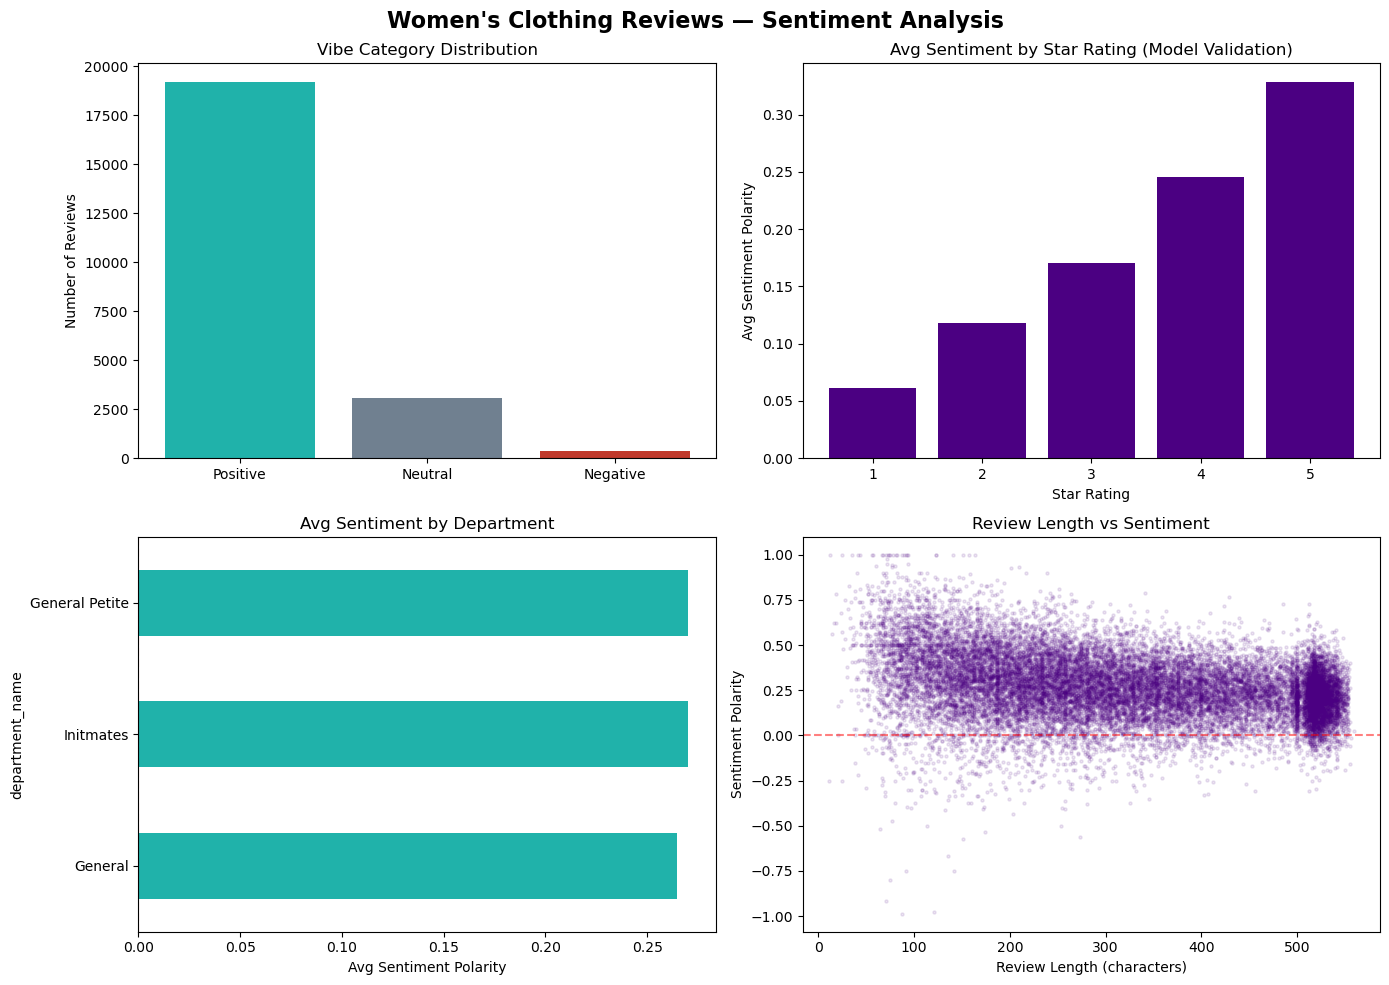

 Visualizations complete!


In [11]:
# Phase 7 — Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Women\'s Clothing Reviews — Sentiment Analysis', 
             fontsize=16, fontweight='bold')

# Chart 1 — Vibe distribution
vibe_counts = df['vibe_category'].value_counts()
axes[0,0].bar(vibe_counts.index, vibe_counts.values, 
               color=['#20B2AA', '#708090', '#C0392B'])
axes[0,0].set_title('Vibe Category Distribution')
axes[0,0].set_ylabel('Number of Reviews')

# Chart 2 — Sentiment by Rating (validation)
avg_by_rating = df.groupby('rating')['sentiment_polarity'].mean()
axes[0,1].bar(avg_by_rating.index.astype(int), avg_by_rating.values, 
               color='#4B0082')
axes[0,1].set_title('Avg Sentiment by Star Rating (Model Validation)')
axes[0,1].set_xlabel('Star Rating')
axes[0,1].set_ylabel('Avg Sentiment Polarity')

# Chart 3 — Department leaderboard
if 'department_name' in df.columns:
    dept_sentiment = (df.groupby('department_name')['sentiment_polarity']
                     .mean().sort_values())
    dept_sentiment.plot(kind='barh', ax=axes[1,0], color='#20B2AA')
    axes[1,0].set_title('Avg Sentiment by Department')
    axes[1,0].set_xlabel('Avg Sentiment Polarity')
    axes[1,0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Chart 4 — Review length vs sentiment
axes[1,1].scatter(df['review_length'], df['sentiment_polarity'], 
                   alpha=0.1, color='#4B0082', s=5)
axes[1,1].set_title('Review Length vs Sentiment')
axes[1,1].set_xlabel('Review Length (characters)')
axes[1,1].set_ylabel('Sentiment Polarity')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(r'C:\Users\larou\Desktop\Retail Data Analysis\Retail-Data-Analysis\sentiment_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(" Visualizations complete!")

## Phase 8: Data Quality Fix — Keyword Cleaning & Age Banding

**Problems identified in Phase 4 output:**
- `key_keywords` contains noise — stopwords like "i", typos like "hte",  
  size indicators like "xs", "petite" that aren't product attributes
- `age` column is raw numbers — hard to analyze age group trends

**Solutions applied:**
- Re-clean keywords using expanded stopword list
- Create `age_band` column with meaningful intervals (18-25, 26-35, etc.)
- Create `mismatch_flag` — identifies reviews where rating and sentiment disagree

In [12]:
# Phase 8 — Final Data Quality Fix

def clean_keywords_final(text: str) -> str:
    """Final keyword cleaning — removes all noise."""
    if pd.isna(text) or str(text).strip() == '':
        return ''
    words = [w.strip().lower() for w in str(text).split(',')]
    words = [w for w in words 
             if w not in STOPWORDS 
             and len(w) > 2
             and not w.isdigit()]
    return ', '.join(sorted(set(words)))

def make_age_band(age) -> str:
    """Groups raw age into meaningful business segments."""
    try:
        age = int(age)
        if age <= 25:  return '18-25'
        elif age <= 35: return '26-35'
        elif age <= 45: return '36-45'
        elif age <= 55: return '46-55'
        else:           return '56+'
    except:
        return 'Unknown'

# Apply cleaning
print("Cleaning keywords...")
df['key_keywords'] = df['key_keywords'].apply(clean_keywords_final)

# Age banding
print("Creating age bands...")
df['age_band'] = df['age'].apply(make_age_band)

# Mismatch flag — where rating and sentiment disagree
df['mismatch_flag'] = np.where(
    ((df['rating'] <= 2) & (df['sentiment_polarity'] >= 0.1)) |
    ((df['rating'] >= 4) & (df['sentiment_polarity'] <= -0.1)),
    1, 0
)

print(f"\n Cleaning complete!")
print(f"\nAge band distribution:")
print(df['age_band'].value_counts().sort_index())
print(f"\nMismatch detected in: {df['mismatch_flag'].sum():,} reviews")
print(f"Mismatch rate: {df['mismatch_flag'].mean()*100:.1f}%")
print(f"\nSample cleaned keywords:")
print(df['key_keywords'].head(10).to_string())

Cleaning keywords...
Creating age bands...

 Cleaning complete!

Age band distribution:
age_band
18-25    1187
26-35    5493
36-45    7093
46-55    4747
56+      4121
Name: count, dtype: int64

Mismatch detected in: 1,243 reviews
Mismatch rate: 5.5%

Sample cleaned keywords:
0      silky, wonderful
1           dress, sooo
2         design, major
3    favorite, jumpsuit
4     flattering, shirt
5          dress, skirt
6       cagrcoal, color
7       shimmer, skirts
8         dress, little
9             fun, such


# Phase 9: Final Export

Saving the fully enriched dataset to the project Data/Processed/ folder  
for use in the Power BI dashboard.

### Note: This is a comment block explaining what the final dataset includes:
- All original columns
- full_review -- combined text for NLP
- review_length -- character count
- sentiment_polarity -- NLP score (-1 to +1)
- sentiment_subjectivity -- opinion vs fact score
- vibe_category -- Positive / Neutral / Negative
- key_keywords -- cleaned product attribute keywords
- age_band -- grouped age segments
- mismatch_flag -- rating vs sentiment disagreement

### Add your actual export code here, for example:
df_final.to_csv('Data/Processed/enriched_reviews.csv', index=False)

In [13]:
# Phase 9 — Final Export 

output_path = r'C:\Users\larou\Desktop\Retail Data Analysis\Retail-Data-Analysis\Data\Processed\Enriched_Womens_Clothing_Reviews.csv'

df.to_csv(output_path, index=False)

print("=" * 50)
print("PIPELINE COMPLETE!")
print("=" * 50)
print(f"Saved to: {output_path}")
print(f" Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Final columns ({df.shape[1]} total):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")
print("\n Ready for Power BI dashboarding!")

PIPELINE COMPLETE!
Saved to: C:\Users\larou\Desktop\Retail Data Analysis\Retail-Data-Analysis\Data\Processed\Enriched_Womens_Clothing_Reviews.csv
 Final shape: 22,641 rows × 20 columns

 Final columns (20 total):
    1. transaction_id
    2. clothing_id
    3. age
    4. title
    5. review_text
    6. rating
    7. is_recommended
    8. positive_feedback_count
    9. department_name
   10. department_name.1
   11. class_name
   12. review_length
   13. full_review
   14. sentiment_polarity
   15. sentiment_subjectivity
   16. vibe_category
   17. key_keywords
   18. negative_keywords
   19. age_band
   20. mismatch_flag

 Ready for Power BI dashboarding!
